Creates 100 kb windows, exports TE elements as BED (center-point), converts genes/satellites from GFF3, runs bigWigAverageOverBed for epigenetic marks. Computes Spearman correlation matrix. Violin plots of distance to nearest CenH3 unit.
Input: Lsyl genome, ChIP-seq/EM-seq BigWigs, element tables, gene/satellite GFF3
Output: data/local_patterns/Lsyl/merged_bin_info.tab, correlation heatmaps

In [ ]:
import pybedtools
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from itertools import combinations
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests


This script creates windows in Juncus effusus genome and then calculates a number of statistics for each window. Then it creates a correlation matrix for the statistics.

In [6]:
# inputs
genome = "data/local_patterns/Jeff_ref/Juncus_effusus.fa"
chr_sizes = "data/local_patterns/Jeff_ref/chrom.sizes"

all_partial = "data/partial_elements_dante.tsv"
all_intact = "data/intact_elements_dante.tsv"
all_solo = "data/solo_elements.tsv"
genes = "data/local_patterns/Jeff/Jeff_helixer.gff3"
satellites = "data/local_patterns/Jeff/Jeff_tidehunter.gff3"


cenh3 = "data/chip-seq_juncus/bigwig/cenh3_merged-input.log2.RPKM.comp.bw"
h3k4 = "data/chip-seq_juncus/bigwig/h3k4me3_merged-input.log2.RPKM.comp.bw"
h3k9 = "data/chip-seq_juncus/bigwig/h3k9me2_merged-input.log2.RPKM.comp.bw"
cpg = "data/methylation_juncus/bigwigs/CpG_context.bw"
chg = "data/methylation_juncus/bigwigs/CHG_context.bw"
chh = "data/methylation_juncus/bigwigs/CHH_context.bw"

window_size = 100_000
step_size = 100_000

First, filter the element tables to only include Juncus effusus elements.

In [9]:
intact_df = pd.read_csv(all_intact, sep="\t")
partial_df = pd.read_csv(all_partial, sep="\t")
solo_df = pd.read_csv(all_solo, sep="\t")

# filter to Juncus effusus elements only
intact_df = intact_df[intact_df['sample']=='Juncus_effusus']
partial_df = partial_df[partial_df['sample']=='Juncus_effusus']
solo_df = solo_df[solo_df['sample']=='Juncus_effusus']

Split the elements by family and export as bed.
Since we are more interested in the number of features rather than the coverage, we will use the center option when exporting to bed (this will convert the features to a single center coordinate).

In [12]:
def export_to_bed(df, output_file, chr_col="chr", start_col="start", end_col="end", name_col=None, score_col=None, center=False):
    """
    Export a DataFrame to a BED file.
    Presume that the coordinates are 1-based.
    The output only has three columns: chromosome, start, and end.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
        output_file (str): The output BED file path.
        chr_col (str): Column name for chromosome. Defaults to "chr".
        start_col (str): Column name for start position. Defaults to "start".
        end_col (str): Column name for end position. Defaults to "end".
        center (bool): If True, convert the feature to a single center coordinate.
                    Ideal for accounting for the number of features 
                    rather than their size. Defaults to False.
    """
    # Select required columns
    bed_columns = [chr_col, start_col, end_col]

    if name_col:
        bed_columns.append(name_col)
    if score_col:
        bed_columns.append(score_col)
    # convert to 0-based coordinates
    df[start_col] = df[start_col] - 1

    # convert feature to a single center coordinate
    if center:
        df[start_col] = df[start_col] + ((df[end_col] - df[start_col]) // 2)
        df[end_col] = df[start_col] + 1  # to get bed with length 1

    # Sort
    df = df.sort_values(by=[chr_col, start_col])
    # Reorder and export as BED
    bed_df = df[bed_columns]
    bed_df.to_csv(output_file, sep='\t', header=False, index=False)

export_to_bed(solo_df, "data/local_patterns/Jeff/solo.bed", center=True)
export_to_bed(intact_df, "data/local_patterns/Jeff/full.bed", center=True)
export_to_bed(partial_df, "data/local_patterns/Jeff/partial.bed", center=True)

export_to_bed(solo_df, "data/local_patterns/Jeff/solo_dist.bed", center=False, name_col="Class")
export_to_bed(intact_df, "data/local_patterns/Jeff/full_dist.bed", center=False, name_col="Class")
export_to_bed(partial_df, "data/local_patterns/Jeff/partial_dist.bed", center=False, name_col="Class")

intact_df["Class_identity"] = intact_df["Class"] + "_"+ intact_df["LTR_identity"].astype(str)
export_to_bed(intact_df, "data/local_patterns/Jeff/full_dist_identity.bed", center=False, name_col="Class_identity")

In [13]:
# Function to save grouped data as BED files
def save_grouped_as_bed(df, output_dir, group_col="Class", chr_col="chr", start_col="start", end_col="end"):
    """
    Group a DataFrame by a specified column and save each group as a BED file.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
        output_dir (str): Directory to save the BED files.
        group_col (str): Column name to group by. Defaults to "Class".
        chr_col (str): Column name for chromosome. Defaults to "chr".
        start_col (str): Column name for start position. Defaults to "start".
        end_col (str): Column name for end position. Defaults to "end".
    """
    os.makedirs(output_dir, exist_ok=True)

    for group_name, group_df in df.groupby(group_col):
        safe_group_name = group_name.replace("/", "_").replace(" ", "_")
        output_file = os.path.join(output_dir, f"{safe_group_name}.bed")
        export_to_bed(group_df, output_file, chr_col, start_col, end_col, center=True)

# Save grouped solo, full, and partial tables as BED files
save_grouped_as_bed(solo_df, "data/local_patterns/Jeff/transposon_bed_files/solo_by_class")
save_grouped_as_bed(intact_df, "data/local_patterns/Jeff/transposon_bed_files/intact_by_class")
save_grouped_as_bed(partial_df, "data/local_patterns/Jeff/transposon_bed_files/partial_by_class")

Also create bed files for LTR identity (proxy for element age) for all full elements and Angela; Athila; Ivana elements. 

In [14]:
export_to_bed(intact_df, "data/local_patterns/Jeff/transposon_bed_files/identity.bed", score_col="LTR_identity")

In [4]:

def gff3_to_bed(gff3_path, output_bed, feature_type=None, center=False):
    """Convert GFF3 to BED, optionally filtering by feature type."""
    cols = ['chr','source','feature_type','start','end','score','strand','phase','attributes']
    df = pd.read_csv(gff3_path, sep='\t', comment='#', names=cols, 
                     dtype={'start': int, 'end': int})
    if feature_type:
        df = df[df['feature_type'] == feature_type]
    # GFF3 is 1-based, BED is 0-based
    df['start'] = df['start'] - 1
    if center:
        df['start'] = df['start'] + (df['end'] - df['start']) // 2
        df['end'] = df['start'] + 1
        # skip "JAMRDH*" scaffolds
    df = df[~df['chr'].str.startswith("JAMRDH")]
    df[['chr','start','end']].sort_values(['chr','start']).to_csv(
        output_bed, sep='\t', header=False, index=False)

# Genes — use 'gene' feature to avoid double-counting transcripts/exons
gff3_to_bed(genes, "data/local_patterns/Jeff/transposon_bed_files/genes.bed", 
            feature_type="gene", center=True)

# Satellites — TideHunter GFF3 typically uses 'repeat_region' or 'satellite'
# Check what feature_type your file uses:
sat_df = pd.read_csv(satellites, sep='\t', comment='#', 
                     names=['chr','source','feature_type','start','end',
                            'score','strand','phase','attributes'])
print(sat_df['feature_type'].value_counts())  # check this first!

# Then use the appropriate feature_type:
gff3_to_bed(satellites, "data/local_patterns/Jeff/transposon_bed_files/satellites.bed",
            feature_type="tandem_repeat",  # adjust based on output above
            center=False)

feature_type
tandem_repeat    8048
Name: count, dtype: int64


Make windows.
```
bedtools makewindows -g data/local_patterns/Jeff_ref/chrom.sizes -w 100000 | awk 'BEGIN{OFS="\t"}{print $1,$2,$3,$1":"$2"-"$3}' > data/local_patterns/Jeff_bins.bed
```

Next, convert bed to bigwig.
```

conda activate /storage/plzen1/home/kratka/.conda/envs/merge_chunks/ # metacentrum env
# prepare bedgraph and convert to bigwig for each bed
#!/usr/bin/env bash
set -euo pipefail

SIZES="data/local_patterns/Jeff_ref/chrom.sizes"
BINS="data/local_patterns/Jeff_bins.bed"
ROOT="data/local_patterns/Jeff"

# sanity checks
[[ -s "$SIZES" ]] || { echo "Missing chrom sizes: $SIZES" >&2; exit 1; }
[[ -s "$BINS"  ]] || { echo "Missing bins BED: $BINS"  >&2; exit 1; }

# 0-terminated to be safe with any filename
find "$ROOT" -type f -iname '*.bed' -print0 \
| while IFS= read -r -d '' bed; do
  base="${bed%.*}"                  # drop .bed
  bg="${base}.bg"
  bw="${base}.bw"
  tab="${base}.tab"

  echo "[*] ${bed}"
  bedtools sort -i "$bed" \
  | bedtools genomecov -i - -g "$SIZES" -bg > "$bg"

  if [ -s "$bg" ]; then
    bedGraphToBigWig "$bg" "$SIZES" "$bw"
    # summarize the BigWig over your bins
    bigWigAverageOverBed "$bw" "$BINS" "$tab"
  else
    echo "    (empty coverage; skipping BigWig)"
  fi
done
```

for identity.bed, there is a slight difference to count with score instead of coverage:
```
bed=data/local_patterns/Jeff/transposon_bed_files/identity.bed
bw=data/local_patterns/Jeff/transposon_bed_files/identity.bw 
tab=data/local_patterns/Jeff/transposon_bed_files/identity.tab
bedGraphToBigWig "$bed" "$SIZES" "$bw"
bigWigAverageOverBed "$bw" "$BINS" "$tab"

```

calculate average in windows for epigenetic features
```bash
bigWigAverageOverBed data/chip-seq_juncus/bigwig/cenh3_merged-input.log2.RPKM.comp.bw data/local_patterns/Jeff_bins.bed data/local_patterns/Jeff/CenH3_average.tab
bigWigAverageOverBed data/methylation_juncus/bigwigs/CpG_context.bw data/local_patterns/Jeff_bins.bed data/local_patterns/Jeff/CpG.tab
bigWigAverageOverBed data/methylation_juncus/bigwigs/CHG_context.bw data/local_patterns/Jeff_bins.bed data/local_patterns/Jeff/CHG.tab
bigWigAverageOverBed data/methylation_juncus/bigwigs/CHH_context.bw data/local_patterns/Jeff_bins.bed data/local_patterns/Jeff/CHH.tab
bigWigAverageOverBed data/chip-seq_juncus/bigwig/h3k4me3_merged-input.log2.RPKM.comp.bw data/local_patterns/Jeff_bins.bed data/local_patterns/Jeff/H3K4_average.tab
bigWigAverageOverBed data/chip-seq_juncus/bigwig/h3k9me2_merged-input.log2.RPKM.comp.bw data/local_patterns/Jeff_bins.bed data/local_patterns/Jeff/H3K9_average.tab
```

calculate correlation in genomic windows

In [7]:
# Find all .tab files in the folder and subfolders
epigen_files = glob.glob("data/local_patterns/Jeff/epigenetic_tab/*.tab", recursive=True)
transposon_files = glob.glob("data/local_patterns/Jeff/transposon_bed_files/*.tab", recursive=True)

tab_files = epigen_files + transposon_files

# Populate the tabs dictionary
tabs = {}
for tab_file in tab_files:
    key = tab_file  # Use the file name as the key
    tabs[key] = pd.read_csv(tab_file, sep="\t", header=None)

# Verify the dictionary
print(f"Loaded {len(tabs)} .tab files.")


Loaded 14 .tab files.


In [8]:
# Initialize an empty list to store processed dataframes
processed_dfs = []

# Iterate through the dictionary and process each dataframe
for file_name, df in tabs.items():
    # Use the first column as the index (bin names)
    df = df.set_index(0)
    # Select only the fourth column (for coverages), or the fifth column (for identities, CpG, CHG, CHH)
    if "identity" in file_name or "CpG" in file_name or "CHG" in file_name or "CHH" in file_name:
        df = df[[df.columns[4]]]
        # convert 0 to NA
        df.replace(0, pd.NA, inplace=True)
    elif "satellite" in file_name:
    # column 2/column 1 to get coverage without double-counting overlapping satellite annotations
        df = df[[df.columns[1]]].div(df[df.columns[0]], axis=0)
    elif "genes" in file_name or "full" in file_name or "partial" in file_name or "solo" in file_name:
        df = df[[df.columns[1]]]
    else:
        df = df[[df.columns[3]]]
    # Rename the fifth column to the key (file name)
    df.columns = [file_name]
    # Append the processed dataframe to the list
    processed_dfs.append(df)

# Concatenate all processed dataframes along the columns
merged_df = pd.concat(processed_dfs, axis=1)

# Reset the index to make the bin names a column again
merged_df.reset_index(inplace=True)
merged_df.rename(columns={0: "Bin Name"}, inplace=True)

# Verify the merged dataframe
print(merged_df.head())
# Save the merged dataframe for later use
merged_df.to_csv("data/local_patterns/Jeff/merged_bin_info.tab", sep="\t", index=False)

                   Bin Name  \
0       CM050890.1:0-100000   
1  CM050890.1:100000-200000   
2  CM050890.1:200000-300000   
3  CM050890.1:300000-400000   
4  CM050890.1:400000-500000   

   data/local_patterns/Jeff/epigenetic_tab/H3K9_average.tab  \
0                                          -0.344157          
1                                          -0.451699          
2                                          -0.451857          
3                                          -0.264584          
4                                          -0.355500          

   data/local_patterns/Jeff/epigenetic_tab/H3K4_average.tab  \
0                                          -0.537815          
1                                          -0.209944          
2                                          -0.133125          
3                                          -0.478171          
4                                          -0.002757          

   data/local_patterns/Jeff/epigenetic_tab/CHH.tab  \
0

In [ ]:
# df: merged table with one row per bin
# columns: "Bin Name", plus one column per .tab (each contains the per-bin summary, e.g. mean0)
# If you loaded raw .tab files, ensure you extracted the same column (mean0 or mean) for all.

# from each column name, delete "data/local_patterns/transposon_bed_files" (even if only partial) and ".tab"
df = merged_df

# get rid of columns that contain "dist"
df = df[[col for col in df.columns if "dist" not in col]]

# Clean column names
df.columns = df.columns.str.replace("data/local_patterns/Jeff/transposon_bed_files/", "", regex=False)
df.columns = df.columns.str.replace("data/local_patterns/Jeff/epigenetic_tab/", "", regex=False)
df.columns = df.columns.str.replace("_average", "", regex=False)
df.columns = df.columns.str.replace(".tab", "", regex=False)

# 1) Set index and keep only numeric feature columns

df = df.set_index("Bin Name")
# column order
order = [ 'CenH3', 'H3K9', 'H3K4','CpG', 'CHG', 'CHH', 'full' ,'partial',  'solo', 'identity', 'genes', 'satellites']
df = df[order]
X = df.apply(pd.to_numeric, errors="coerce")

# 2) Drop columns that are constant or all-NA (Spearman undefined there)
const_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
if const_cols:
    print("Dropping constant columns:", const_cols)
    X = X.drop(columns=const_cols)

# 3) Compute Spearman correlation matrix (pairwise complete observations)
R = X.corr(method="spearman")

# 4) P-values with FDR over unique pairs (note: anti-conservative if bins are autocorrelated)
cols = list(X.columns)
pairs = list(combinations(cols, 2))

pvals = []
for a, b in pairs:
    r, p = spearmanr(X[a], X[b], nan_policy="omit")
    R.loc[a, b] = R.loc[b, a] = r
    pvals.append(p)

# FDR correction
_, p_adj, _, _ = multipletests(pvals, method="fdr_bh")
P = pd.DataFrame(1.0, index=cols, columns=cols)
for (a, b), pa in zip(pairs, p_adj):
    P.loc[a, b] = P.loc[b, a] = pa
np.fill_diagonal(P.values, 0.0)

# Example: mask for non-significant cells at q>0.05
sig_mask = P <= 0.01

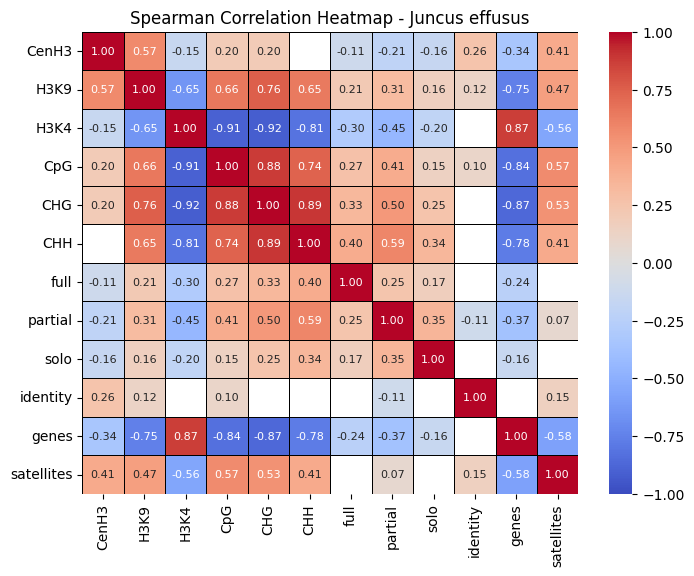

In [11]:


# heatmap of correlations
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(R, cmap="coolwarm", vmin=-1, vmax=1, mask=~sig_mask, annot=True, fmt=".2f", annot_kws={"size": 8},
linewidths=0.5, linecolor='black')
plt.title("Spearman Correlation Heatmap - Juncus effusus")
plt.savefig("data/figures/Jeff_spearman_heatmap.svg", dpi=300)
plt.show()
